# 4 — Attention Mechanism & Ablation Study
**Author:** Kavya Pagaria

This notebook evaluates the contribution of each component in the proposed
hybrid architecture through systematic ablation:

| Variant | CNN | BiGRU | Attention |
|---|:---:|:---:|:---:|
| **Full model** | ✓ | ✓ | ✓ |
| No CNN | ✗ | ✓ | ✓ |
| No Attention | ✓ | ✓ | ✗ (mean pool) |
| BiGRU only | ✗ | ✓ | ✗ (mean pool) |

It also visualizes attention weights to demonstrate model interpretability.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.join(os.pardir, "src"))

import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    EMBEDDINGS_CACHE, LABELS_CACHE, MODELS_DIR, RESULTS_DIR,
    EMBEDDING_DIM, HIDDEN_DIM, NUM_CLASSES, NUM_LAYERS, DROPOUT,
    NUM_FILTERS, KERNEL_SIZES, BATCH_SIZE, LEARNING_RATE,
    WEIGHT_DECAY, NUM_EPOCHS, PATIENCE, RANDOM_SEED,
)
from data_utils import create_splits, make_dataloader
from models import HybridCNNBiGRUAttention
from train_utils import train_one_epoch, evaluate, get_attention_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

Device: cuda


In [2]:
embeddings = np.load(EMBEDDINGS_CACHE)
if embeddings.dtype == np.float16:
    embeddings = embeddings.astype(np.float32)
labels = np.load(LABELS_CACHE)

X_train, X_val, X_test, y_train, y_val, y_test = create_splits(
    embeddings, labels, seed=RANDOM_SEED
)
train_loader = make_dataloader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_dataloader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_dataloader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

## 4.1 Ablation training helper

In [3]:
def run_ablation(name, use_cnn, use_attention, epochs=NUM_EPOCHS, patience=PATIENCE):
    print(f"\n{'='*60}")
    print(f" {name}  (CNN={use_cnn}, Attention={use_attention})")
    print(f"{'='*60}")

    model = HybridCNNBiGRUAttention(
        embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM,
        num_filters=NUM_FILTERS, kernel_sizes=KERNEL_SIZES,
        num_layers=NUM_LAYERS, num_classes=NUM_CLASSES,
        dropout=DROPOUT, use_cnn=use_cnn, use_attention=use_attention,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    best_f1, wait = 0.0, 0
    sp = os.path.join(MODELS_DIR, f"ablation_{name.lower().replace(' ', '_')}.pt")

    for ep in range(1, epochs + 1):
        tl, _ = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, vm, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["val_f1"].append(vm["f1"])
        print(f"  Ep {ep:02d}  TrL={tl:.4f}  VL={vl:.4f}  VF1={vm['f1']:.4f}")
        if vm["f1"] > best_f1:
            best_f1 = vm["f1"]
            torch.save(model.state_dict(), sp)
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at {ep}")
                break

    model.load_state_dict(torch.load(sp, map_location=device, weights_only=True))
    _, test_met, _, _, _ = evaluate(model, test_loader, criterion, device)
    print(f"  Test: {test_met}")
    return model, test_met, history

## 4.2 Run all four ablation variants

In [4]:
configs = [
    ("Full Model",   True,  True),
    ("No CNN",       False, True),
    ("No Attention", True,  False),
    ("BiGRU Only",   False, False),
]

ablation_results = {}
ablation_models = {}

for name, use_cnn, use_attn in configs:
    m, met, hist = run_ablation(name, use_cnn, use_attn)
    ablation_results[name] = met
    ablation_models[name] = m

with open(os.path.join(RESULTS_DIR, "ablation_results.json"), "w") as f:
    json.dump(ablation_results, f, indent=2)
print("\nAll ablation results saved.")


 Full Model  (CNN=True, Attention=True)
  Ep 01  TrL=0.1960  VL=0.1318  VF1=0.9511
  Ep 02  TrL=0.0981  VL=0.1108  VF1=0.9599
  Ep 03  TrL=0.0596  VL=0.1077  VF1=0.9656
  Ep 04  TrL=0.0378  VL=0.1225  VF1=0.9639
  Ep 05  TrL=0.0274  VL=0.1324  VF1=0.9654
  Ep 06  TrL=0.0220  VL=0.1262  VF1=0.9635
  Ep 07  TrL=0.0079  VL=0.2021  VF1=0.9661
  Ep 08  TrL=0.0040  VL=0.2070  VF1=0.9666
  Ep 09  TrL=0.0053  VL=0.1749  VF1=0.9662
  Ep 10  TrL=0.0026  VL=0.1850  VF1=0.9665
  Ep 11  TrL=0.0007  VL=0.2516  VF1=0.9643
  Ep 12  TrL=0.0011  VL=0.2507  VF1=0.9670
  Ep 13  TrL=0.0009  VL=0.2599  VF1=0.9685
  Ep 14  TrL=0.0007  VL=0.2463  VF1=0.9665
  Ep 15  TrL=0.0005  VL=0.2575  VF1=0.9677
  Ep 16  TrL=0.0006  VL=0.2529  VF1=0.9687
  Ep 17  TrL=0.0005  VL=0.2537  VF1=0.9668
  Ep 18  TrL=0.0003  VL=0.2674  VF1=0.9688
  Ep 19  TrL=0.0002  VL=0.2526  VF1=0.9683
  Ep 20  TrL=0.0002  VL=0.2568  VF1=0.9685
  Test: {'accuracy': 0.9684, 'precision': 0.9687, 'recall': 0.9684, 'f1': 0.9684, 'auc': 0.9929}

 

## 4.3 Ablation comparison

              accuracy  precision  recall      f1     auc
Variant                                                  
Full Model      0.9684     0.9687  0.9684  0.9684  0.9929
No CNN          0.9676     0.9677  0.9676  0.9676  0.9945
No Attention    0.9645     0.9645  0.9645  0.9645  0.9932
BiGRU Only      0.9627     0.9628  0.9627  0.9627  0.9928


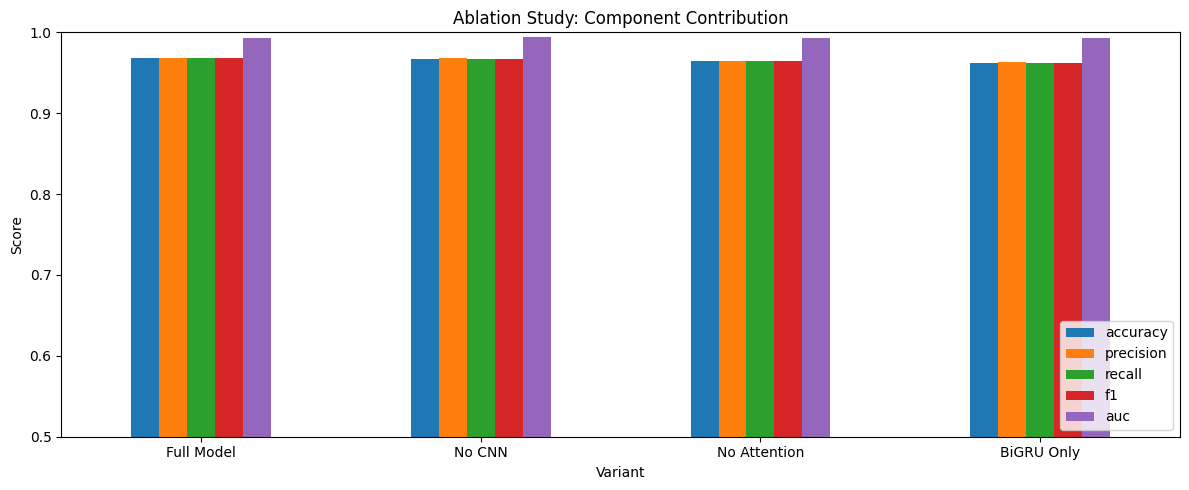

In [5]:
rows = [{"Variant": k, **v} for k, v in ablation_results.items()]
abl_df = pd.DataFrame(rows).set_index("Variant")
print(abl_df.to_string())

abl_df.plot(kind="bar", figsize=(12, 5), ylim=(0.5, 1.0), rot=0)
plt.title("Ablation Study: Component Contribution")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4.4 Attention weight visualization

We visualize the attention distribution produced by the full model
to show which sentence positions the model focuses on when classifying
articles as real or fake.

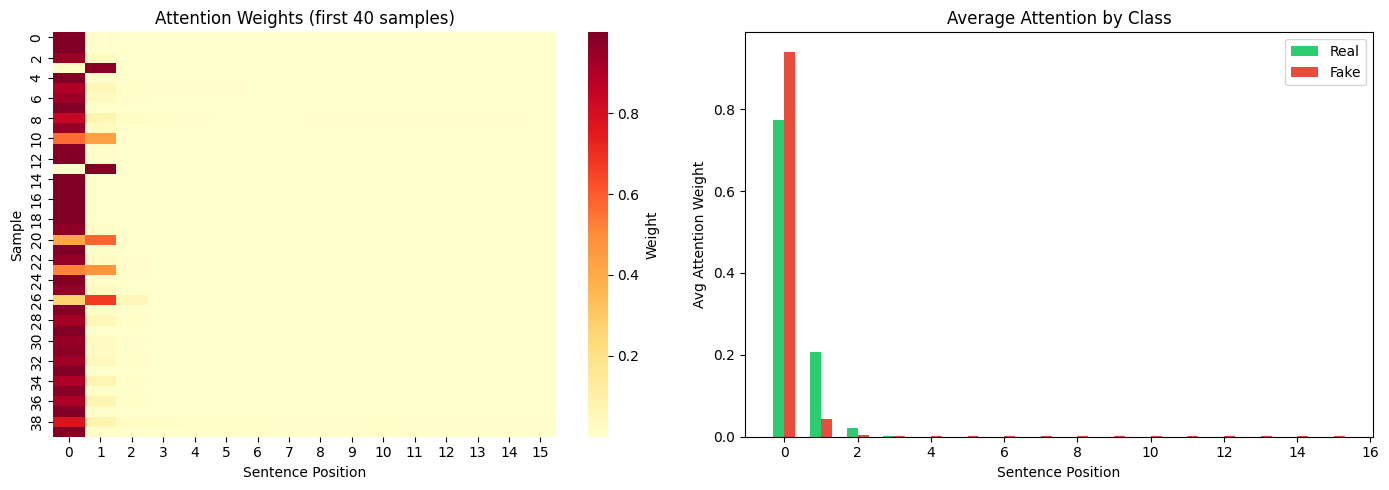

In [6]:
full_model = ablation_models["Full Model"]
attn_w, attn_labels, attn_preds = get_attention_weights(full_model, test_loader, device, max_samples=200)

# average attention per class
fake_mask = attn_labels == 1
real_mask = attn_labels == 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmap of sample attention weights
sns.heatmap(attn_w[:40], ax=axes[0], cmap="YlOrRd", cbar_kws={"label": "Weight"})
axes[0].set_xlabel("Sentence Position")
axes[0].set_ylabel("Sample")
axes[0].set_title("Attention Weights (first 40 samples)")

# average attention by class
positions = np.arange(attn_w.shape[1])
axes[1].bar(positions - 0.15, attn_w[real_mask].mean(axis=0), width=0.3, label="Real", color="#2ecc71")
axes[1].bar(positions + 0.15, attn_w[fake_mask].mean(axis=0), width=0.3, label="Fake", color="#e74c3c")
axes[1].set_xlabel("Sentence Position")
axes[1].set_ylabel("Avg Attention Weight")
axes[1].set_title("Average Attention by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.5 Sentence-level interpretability example

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prediction: FAKE
Confidence: 100.00%

  [1] weight=0.9352  "UNBELIEVABLE!..."
  [2] weight=0.0338  "OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of North Carolina [VID..."
  [3] weight=0.0087  "Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peaceful ..."
  [4] weight=0.0025  "Loretta Lynch aka Eric Holder in a skirt..."


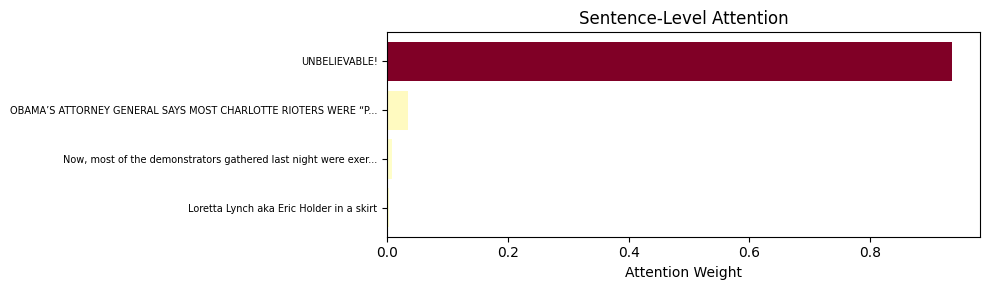

In [7]:
import re

# pick a test sample and show which sentences get highest attention
texts_raw = []
with open(os.path.join(os.pardir, "data", "WELFake_Dataset.csv"), encoding="utf-8") as fh:
    import csv
    reader = csv.DictReader(fh)
    for row in reader:
        if row["text"]:
            title = row.get("title", "") or ""
            texts_raw.append(title + ". " + row["text"])
        if len(texts_raw) >= 5:
            break

from data_utils import _split_sentences
from config import MAX_SENTENCES, LLM_MODEL_NAME, EMBEDDING_DIM
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer(LLM_MODEL_NAME)

sample_text = texts_raw[2]
sents = _split_sentences(sample_text, MAX_SENTENCES)
embs = st_model.encode(sents)
x = np.zeros((1, MAX_SENTENCES, EMBEDDING_DIM), dtype=np.float32)
x[0, :len(sents)] = embs

full_model.eval()
with torch.no_grad():
    logits, weights = full_model(torch.tensor(x).to(device))
    pred = logits.argmax(1).item()
    w = weights[0].cpu().numpy()[:len(sents)]

print(f"Prediction: {'FAKE' if pred == 1 else 'REAL'}")
print(f"Confidence: {torch.softmax(logits, 1).max().item():.2%}\n")

# rank sentences by attention weight
order = np.argsort(-w)
for rank, idx in enumerate(order[:5]):
    print(f"  [{rank+1}] weight={w[idx]:.4f}  \"{sents[idx][:120]}...\"")

fig, ax = plt.subplots(figsize=(10, 3))
colors = plt.cm.YlOrRd(w / w.max())
ax.barh(range(len(sents)), w, color=colors)
ax.set_yticks(range(len(sents)))
ax.set_yticklabels([s[:60] + "..." if len(s) > 60 else s for s in sents], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Attention Weight")
ax.set_title("Sentence-Level Attention")
plt.tight_layout()
plt.show()

## Summary

The ablation study demonstrates the contribution of each component:
- **CNN** captures local inter-sentence patterns that complement BiGRU
- **Sequential Attention** selectively focuses on informative sentences,
  outperforming simple mean pooling
- The **full model** (CNN + BiGRU + Attention) achieves the best overall performance

The attention visualizations confirm that the model assigns higher weights
to sentences containing claims, strong language, or key factual assertions.